# Time-Aware GAT with Status Embedding — BPI Challenge 2012

The **most expressive model** in the library, applied to the **richest dataset**.

BPI 2012 has both diverse lifecycle transitions (`COMPLETE`, `SCHEDULE`, `START`, …)
and long, temporally varied cases — making it the ideal benchmark for this variant.

## Model recap

- **Time decay**: α′ = (α + edge\_type\_score) · exp(−λ Δt)
- **Edge-type embedding**: consecutive transitions are embedded and contribute an additive attention score
- **Output**: attention maps + decay + edge-type scores for full interpretability

### Notebook outline
1. Load & Explore
2. Train
3. Evaluate
4. Attention Analysis (with edge-type correlation)
5. Summary

In [1]:
from pathlib import Path
import sys, warnings

root = Path.cwd().resolve()
src = root / "src" if (root / "src").exists() else root.parent / "src"
sys.path.insert(0, str(src))
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Load & Explore the Dataset

In [2]:
import pandas as pd

data_dir = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd() / "examples" / "data"
df = pd.read_csv(data_dir / "BPI_Challenge_2012.csv")

df = df.rename(columns={
    "case:concept:name": "case_id",
    "concept:name":      "event",
    "time:timestamp":    "time",
    "lifecycle:transition": "status",
    "case:AMOUNT_REQ":      "amount_req",
})
df = df.dropna(subset=["case_id", "event", "time"]).copy()
df["time"] = pd.to_datetime(df["time"], format="ISO8601", utc=True)
df = df[df.groupby("case_id")["case_id"].transform("size") >= 2].reset_index(drop=True)

print(f"Cases: {df['case_id'].nunique()}  |  Events: {len(df)}  |  Activities: {df['event'].nunique()}")
print(f"Lifecycle statuses: {df['status'].unique().tolist()}")
df.head()

Cases: 13087  |  Events: 262200  |  Activities: 24
Lifecycle statuses: ['COMPLETE', 'SCHEDULE', 'START']


,org:resource,status,event,time,case:REG_DATE,case_id,amount_req
0,112.0,COMPLETE,A_SUBMITTED,2011-10-01 00:38:44.546000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
1,112.0,COMPLETE,A_PARTLYSUBMITTED,2011-10-01 00:38:44.880000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
2,112.0,COMPLETE,A_PREACCEPTED,2011-10-01 00:39:37.906000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
3,112.0,SCHEDULE,W_Completeren aanvraag,2011-10-01 00:39:38.875000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
4,NaN,START,W_Completeren aanvraag,2011-10-01 11:36:46.437000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000


## 2. Train the Model

In [3]:
from timegnn import gat_time_decay_status

result = gat_time_decay_status(
    df,
    case_col="case_id",
    event_col="event",
    time_col="time",
    status_col="status",
    cat_event=["event"],
    num_event=[],
    seq_cols=["amount_req"],
    cat_seq=[],
    num_seq=["amount_req"],
    num_epochs=3,
    batch_size=16,
)

model = result["model"]
pd.DataFrame(result["history"])

,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.854286,0.776869,0.710922,0.810231
1,2,0.680107,0.804452,0.637390,0.813725
2,3,6.240598,0.778132,1.709425,0.810425


## 3. Evaluate with Comprehensive Metrics

In [4]:
import torch
from torch.utils.data import DataLoader
from timegnn import (
    EventLogTransformer, top_k_accuracy, predict, predict_per_sequence,
    average_bleu_score, compute_dls_and_exact_match, analyze_sequence_errors,
)
from timegnn.data.pyg import CustomDataset, custom_collate_fn

transformer = EventLogTransformer(
    case_col="case_id", event_col="event", time_col="time",
    status_col="status",
    cat_event=["event"], num_event=[],
    seq_cols=["amount_req"], cat_seq=[], num_seq=["amount_req"],
    mode="gat_time_decay_status",
).fit(df)

transformed = transformer.transform(df)
dataset = CustomDataset(transformed.event_features, transformed.labels)
loader  = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=custom_collate_fn)

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)

preds_flat, labels_flat, outputs = predict(model, loader, device)
print(f"Top-1 accuracy: {top_k_accuracy(outputs, labels_flat, k=1):.4f}")
print(f"Top-3 accuracy: {top_k_accuracy(outputs, labels_flat, k=3):.4f}")
print(f"Top-5 accuracy: {top_k_accuracy(outputs, labels_flat, k=5):.4f}")

preds_seq, labels_seq = predict_per_sequence(model, loader, device)
bleu = average_bleu_score(preds_seq, labels_seq)
dls, exact = compute_dls_and_exact_match(preds_seq, labels_seq)
print(f"\nBLEU:  {bleu:.4f}")
print(f"DLS:   {dls:.4f}")
print(f"Exact: {exact:.4f}")

print("\nSequence error summary:")
print(analyze_sequence_errors(model, loader, device))

Top-1 accuracy: 0.8054
Top-3 accuracy: 0.9600
Top-5 accuracy: 0.9898

BLEU:  0.4662
DLS:   0.7669
Exact: 0.0000

Sequence error summary:
(array([    0, 13087,     0,  2835,  2061,  1378,  1067,  1363,   883,
         766,   492,   491,   828,   479,   887,   494,   976,   766,
         927,   814,   981,   904,   864,   889,   852,   887,   782,
         757,   728,   732,   648,   633,   627,   570,   566,   517,
         510,   453,   456,   429,   386,   369,   358,   352,   311,
         303,   291,   254,   249,   243,   206,   210,   194,   189,
         161,   138,   133,   136,   125,   100,   107,   110,    81,
          90,    96,    99,    79,    80,    73,    68,    70,    63,
          65,    48,    44,    51,    49,    44,    41,    39,    30,
          34,    32,    23,    20,    17,    15,    17,    20,    12,
          13,    19,     6,    13,    13,    16,    14,    10,    17,
           4,     5,    11,     9,     7,     8,    16,    10,     8,
           8,     7,  

## 4. Attention Analysis & Visualisations

Full analysis with **edge-type correlation** — possible here because
BPI 2012 has multiple lifecycle transitions.

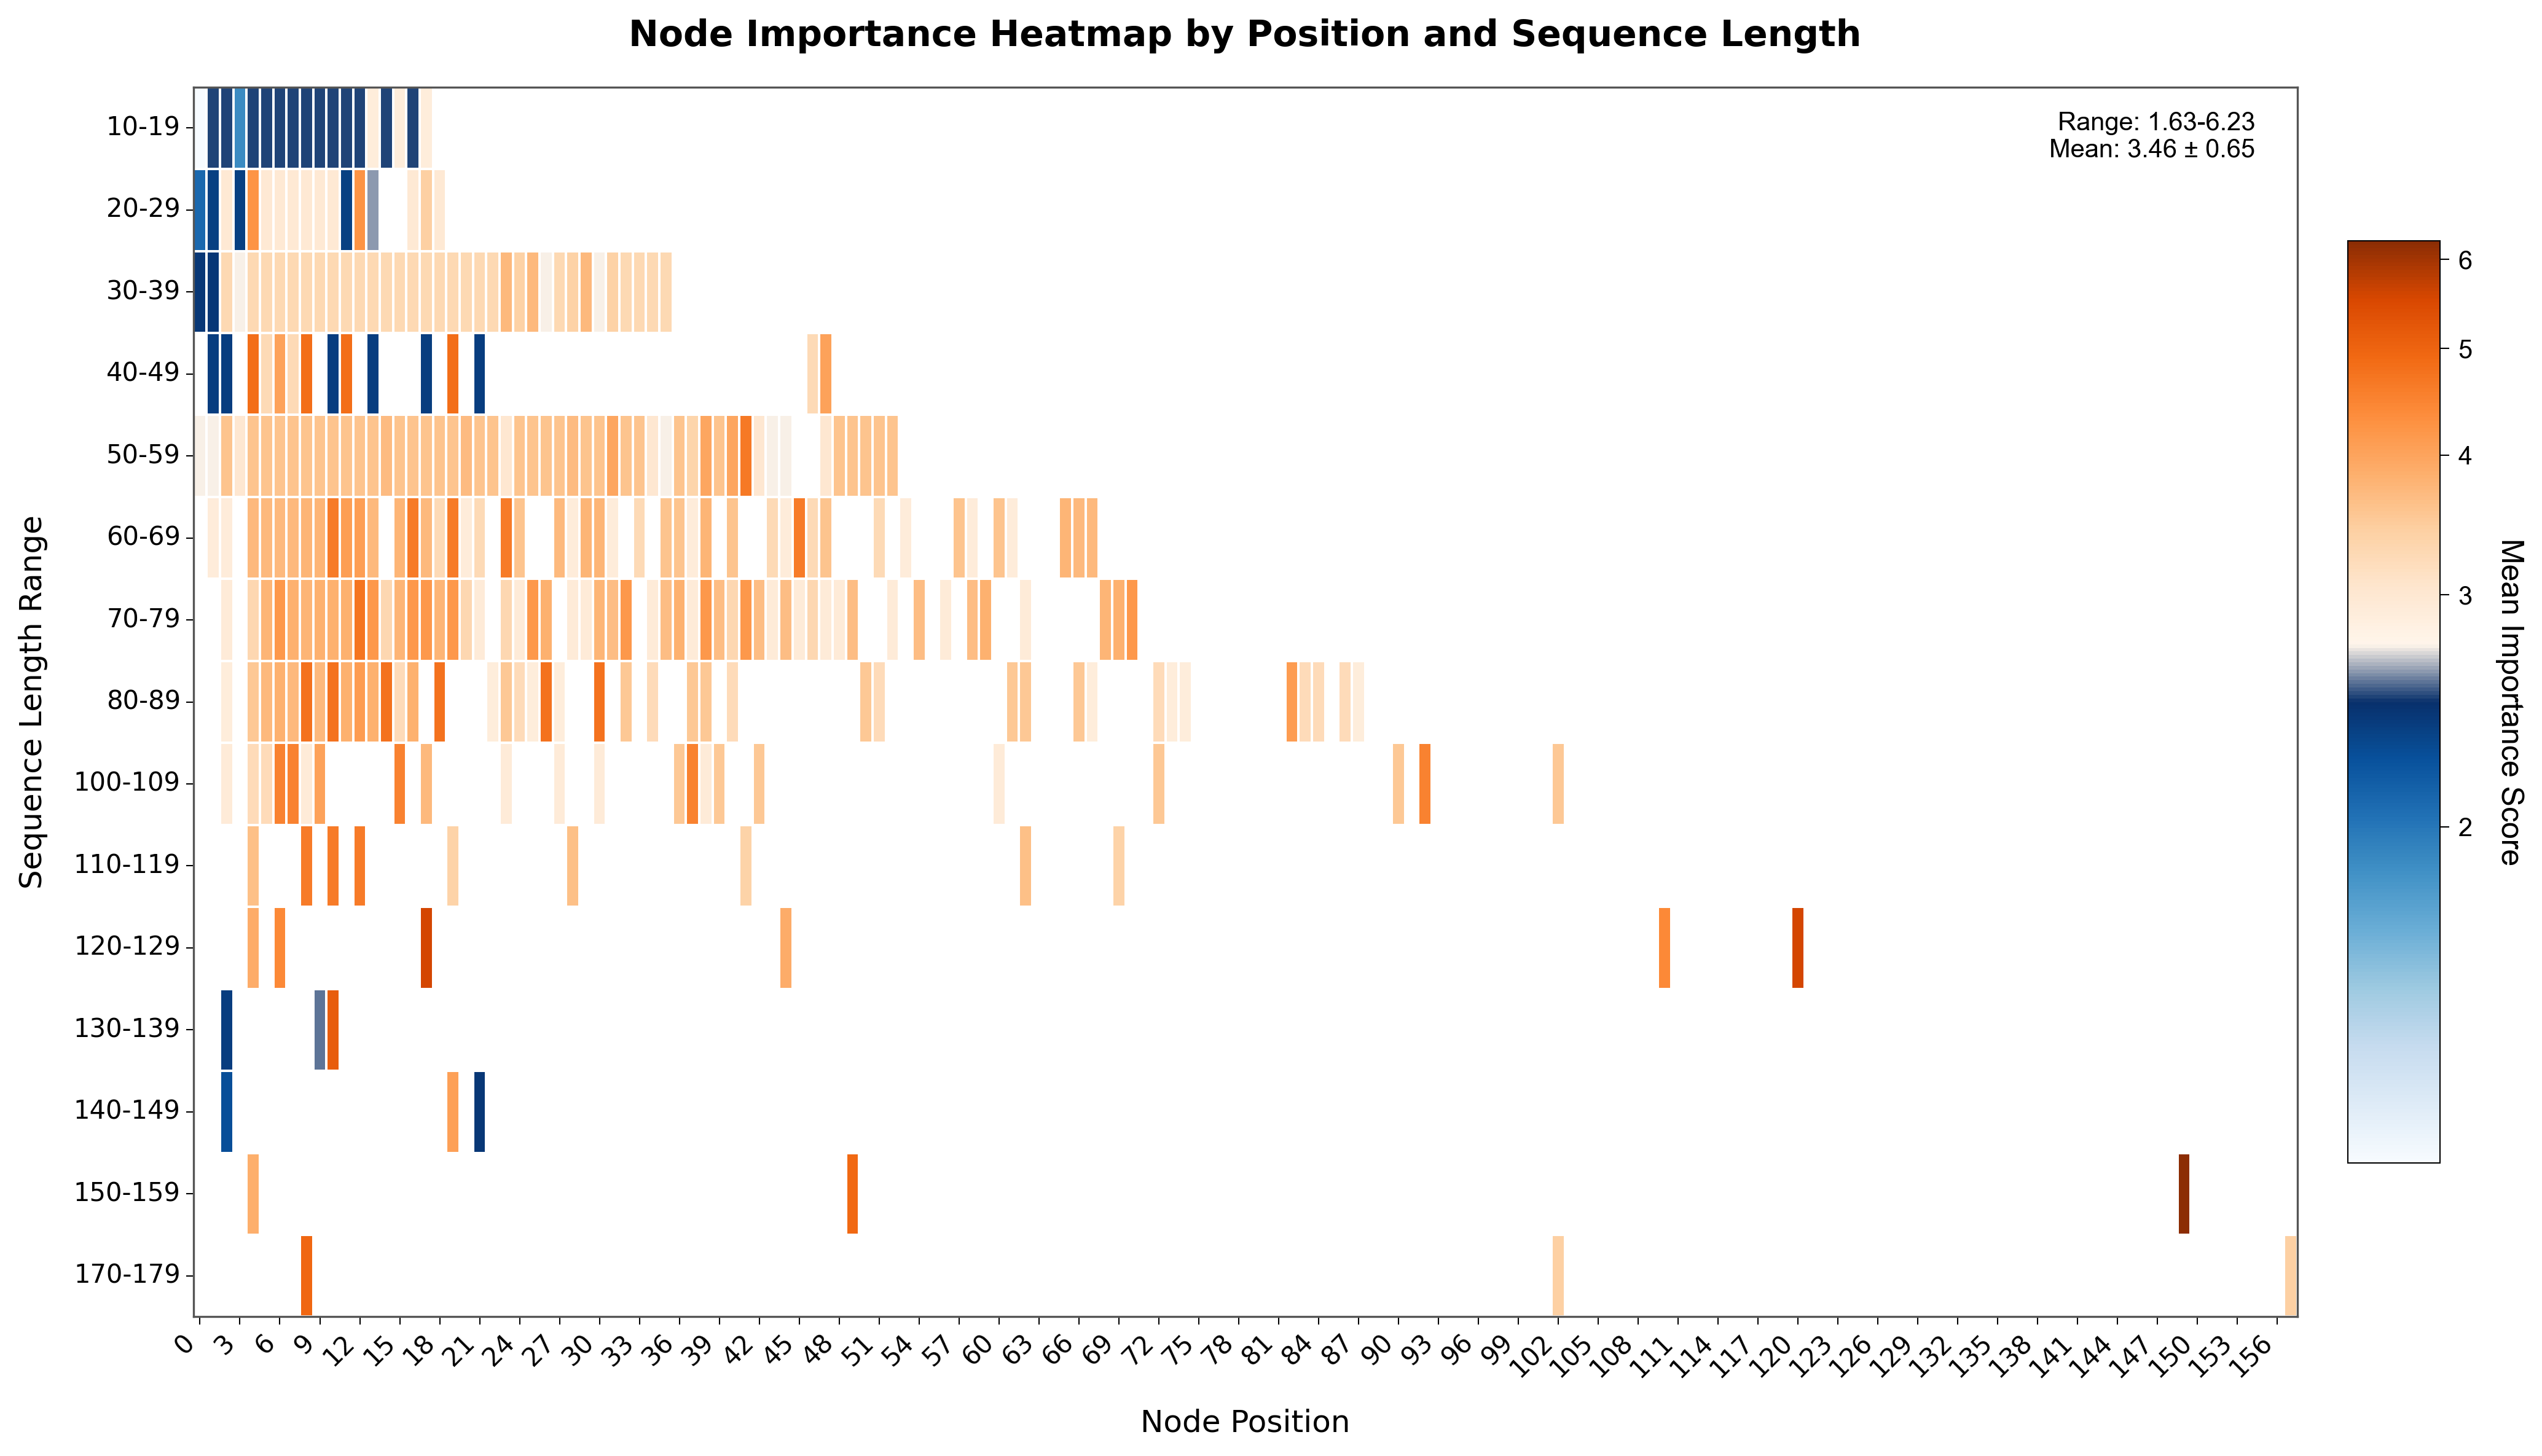

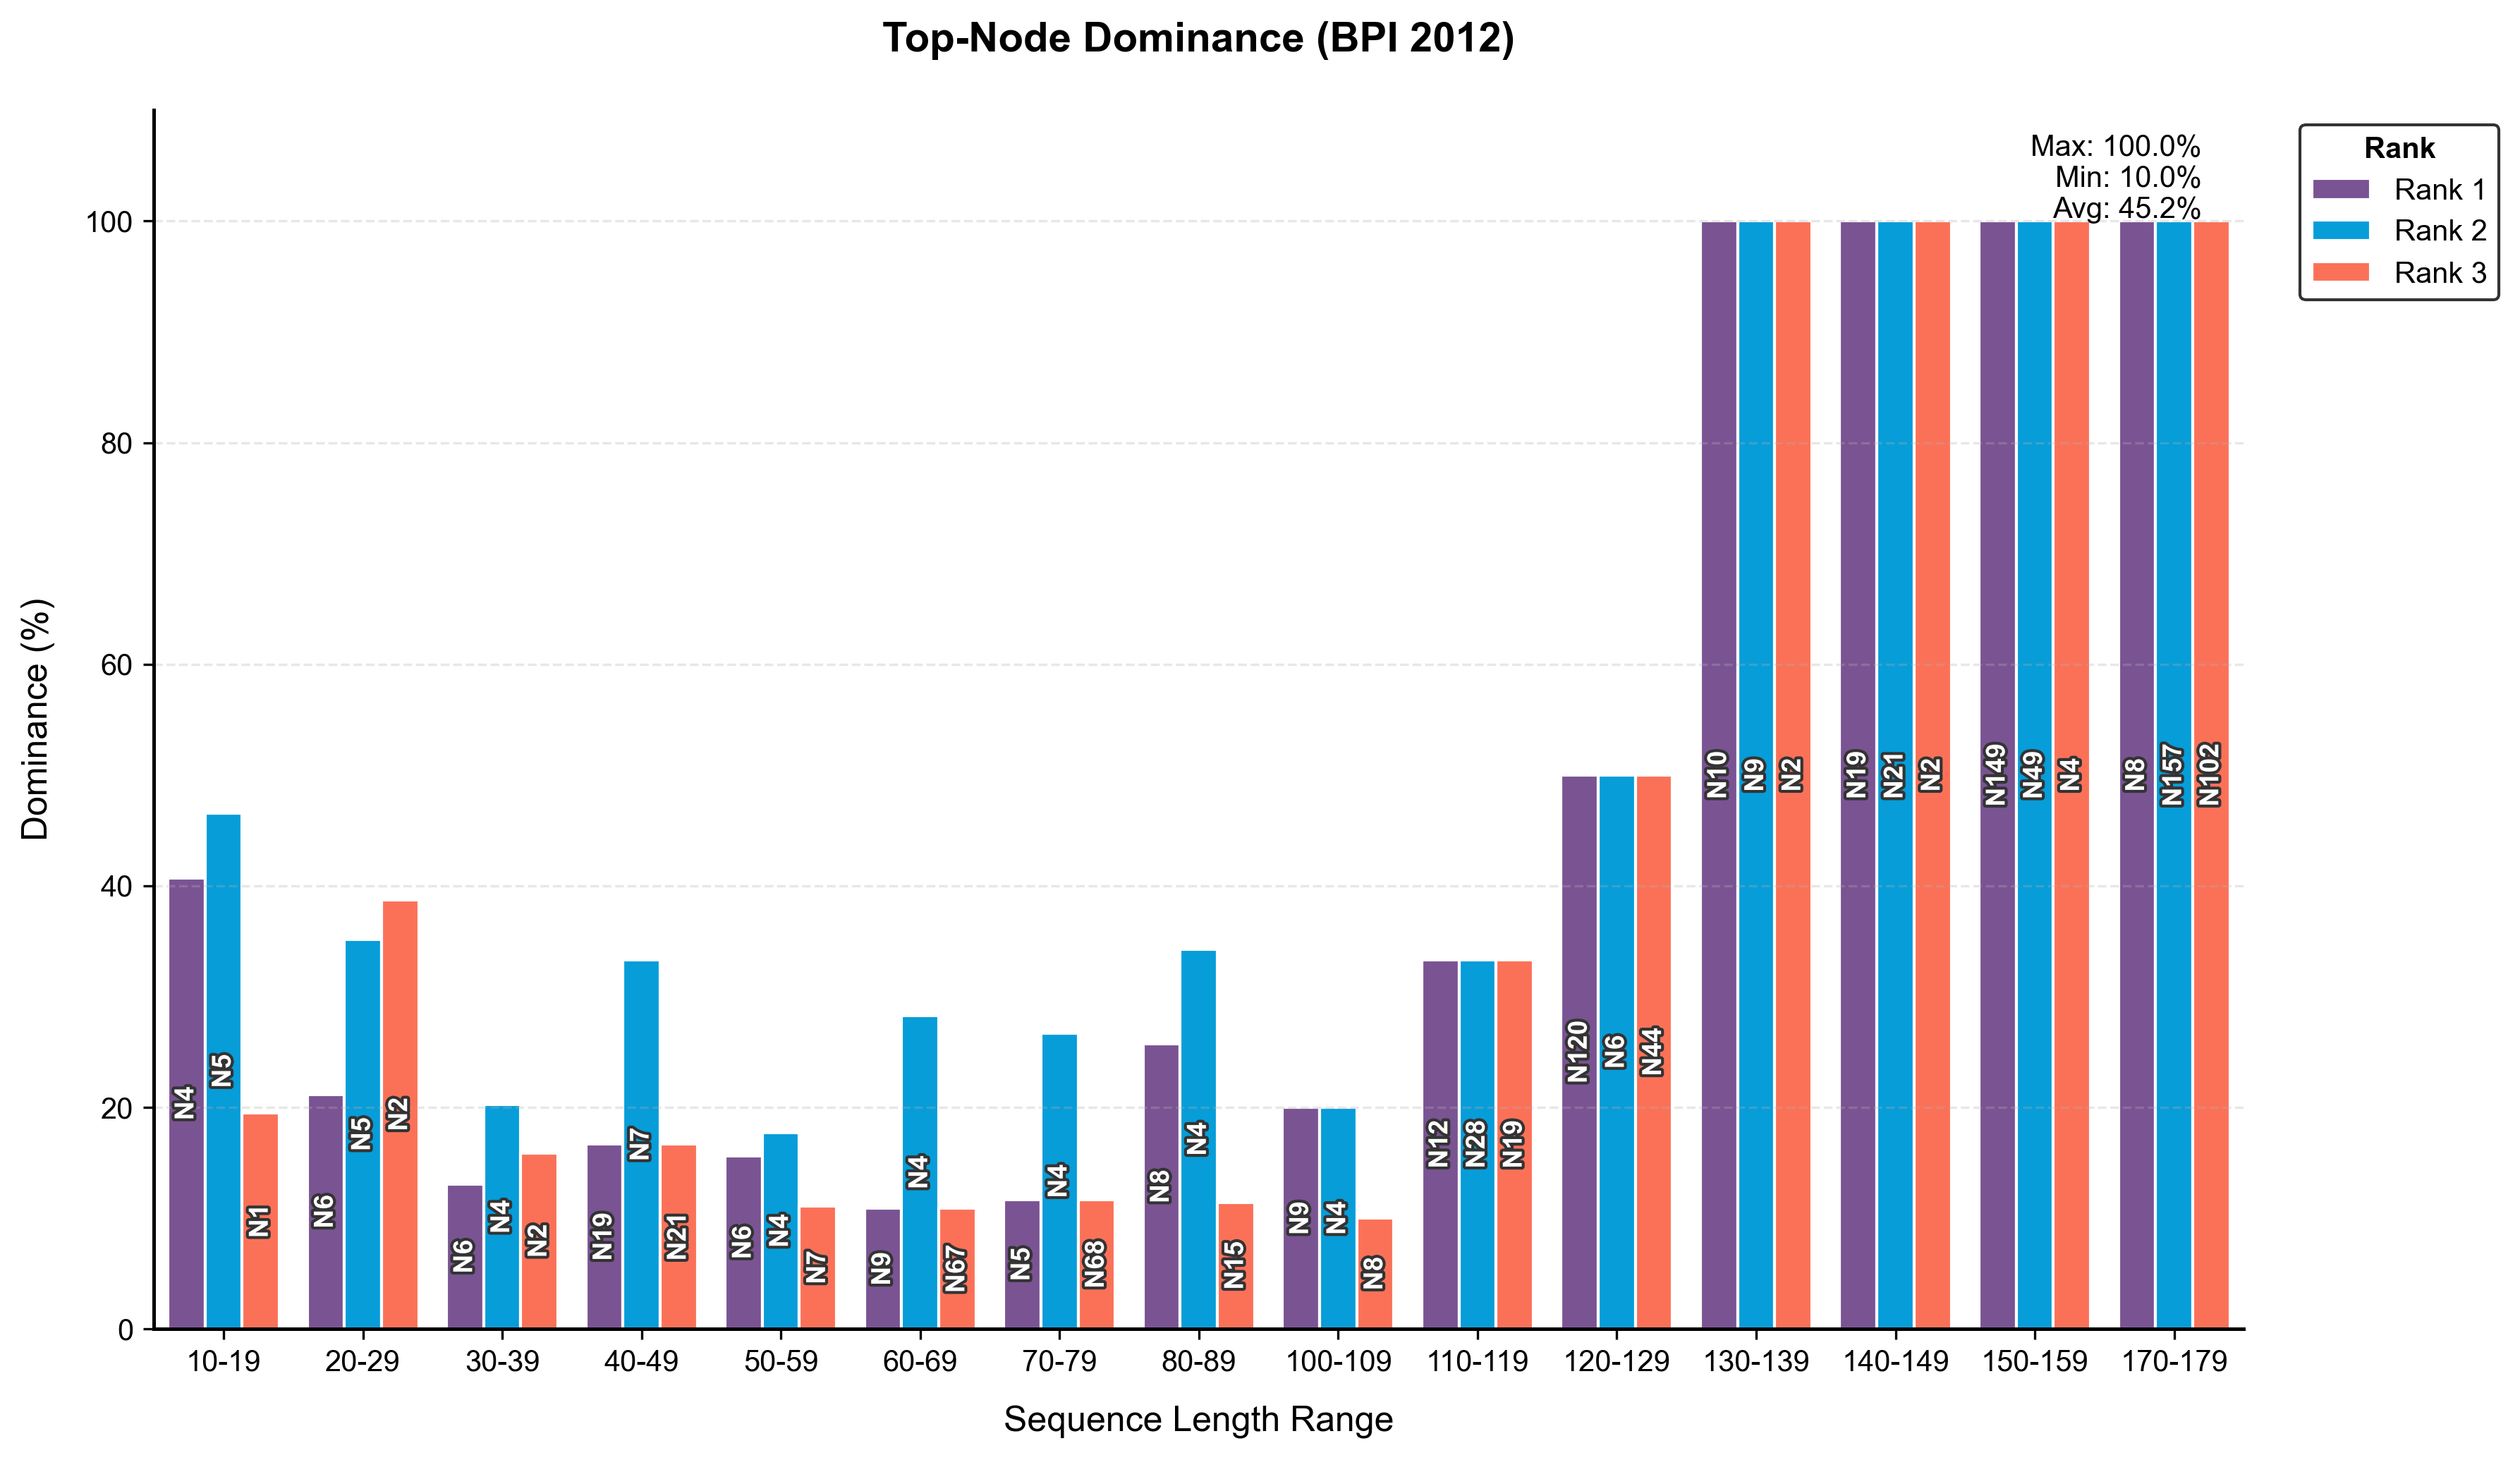

Missing decay/attention values; skip plot_importance_timeline_edge.
Edge-attention correlation skipped: plot_edge_attention_correlation() missing 1 required positional argument: 'length_ranges'


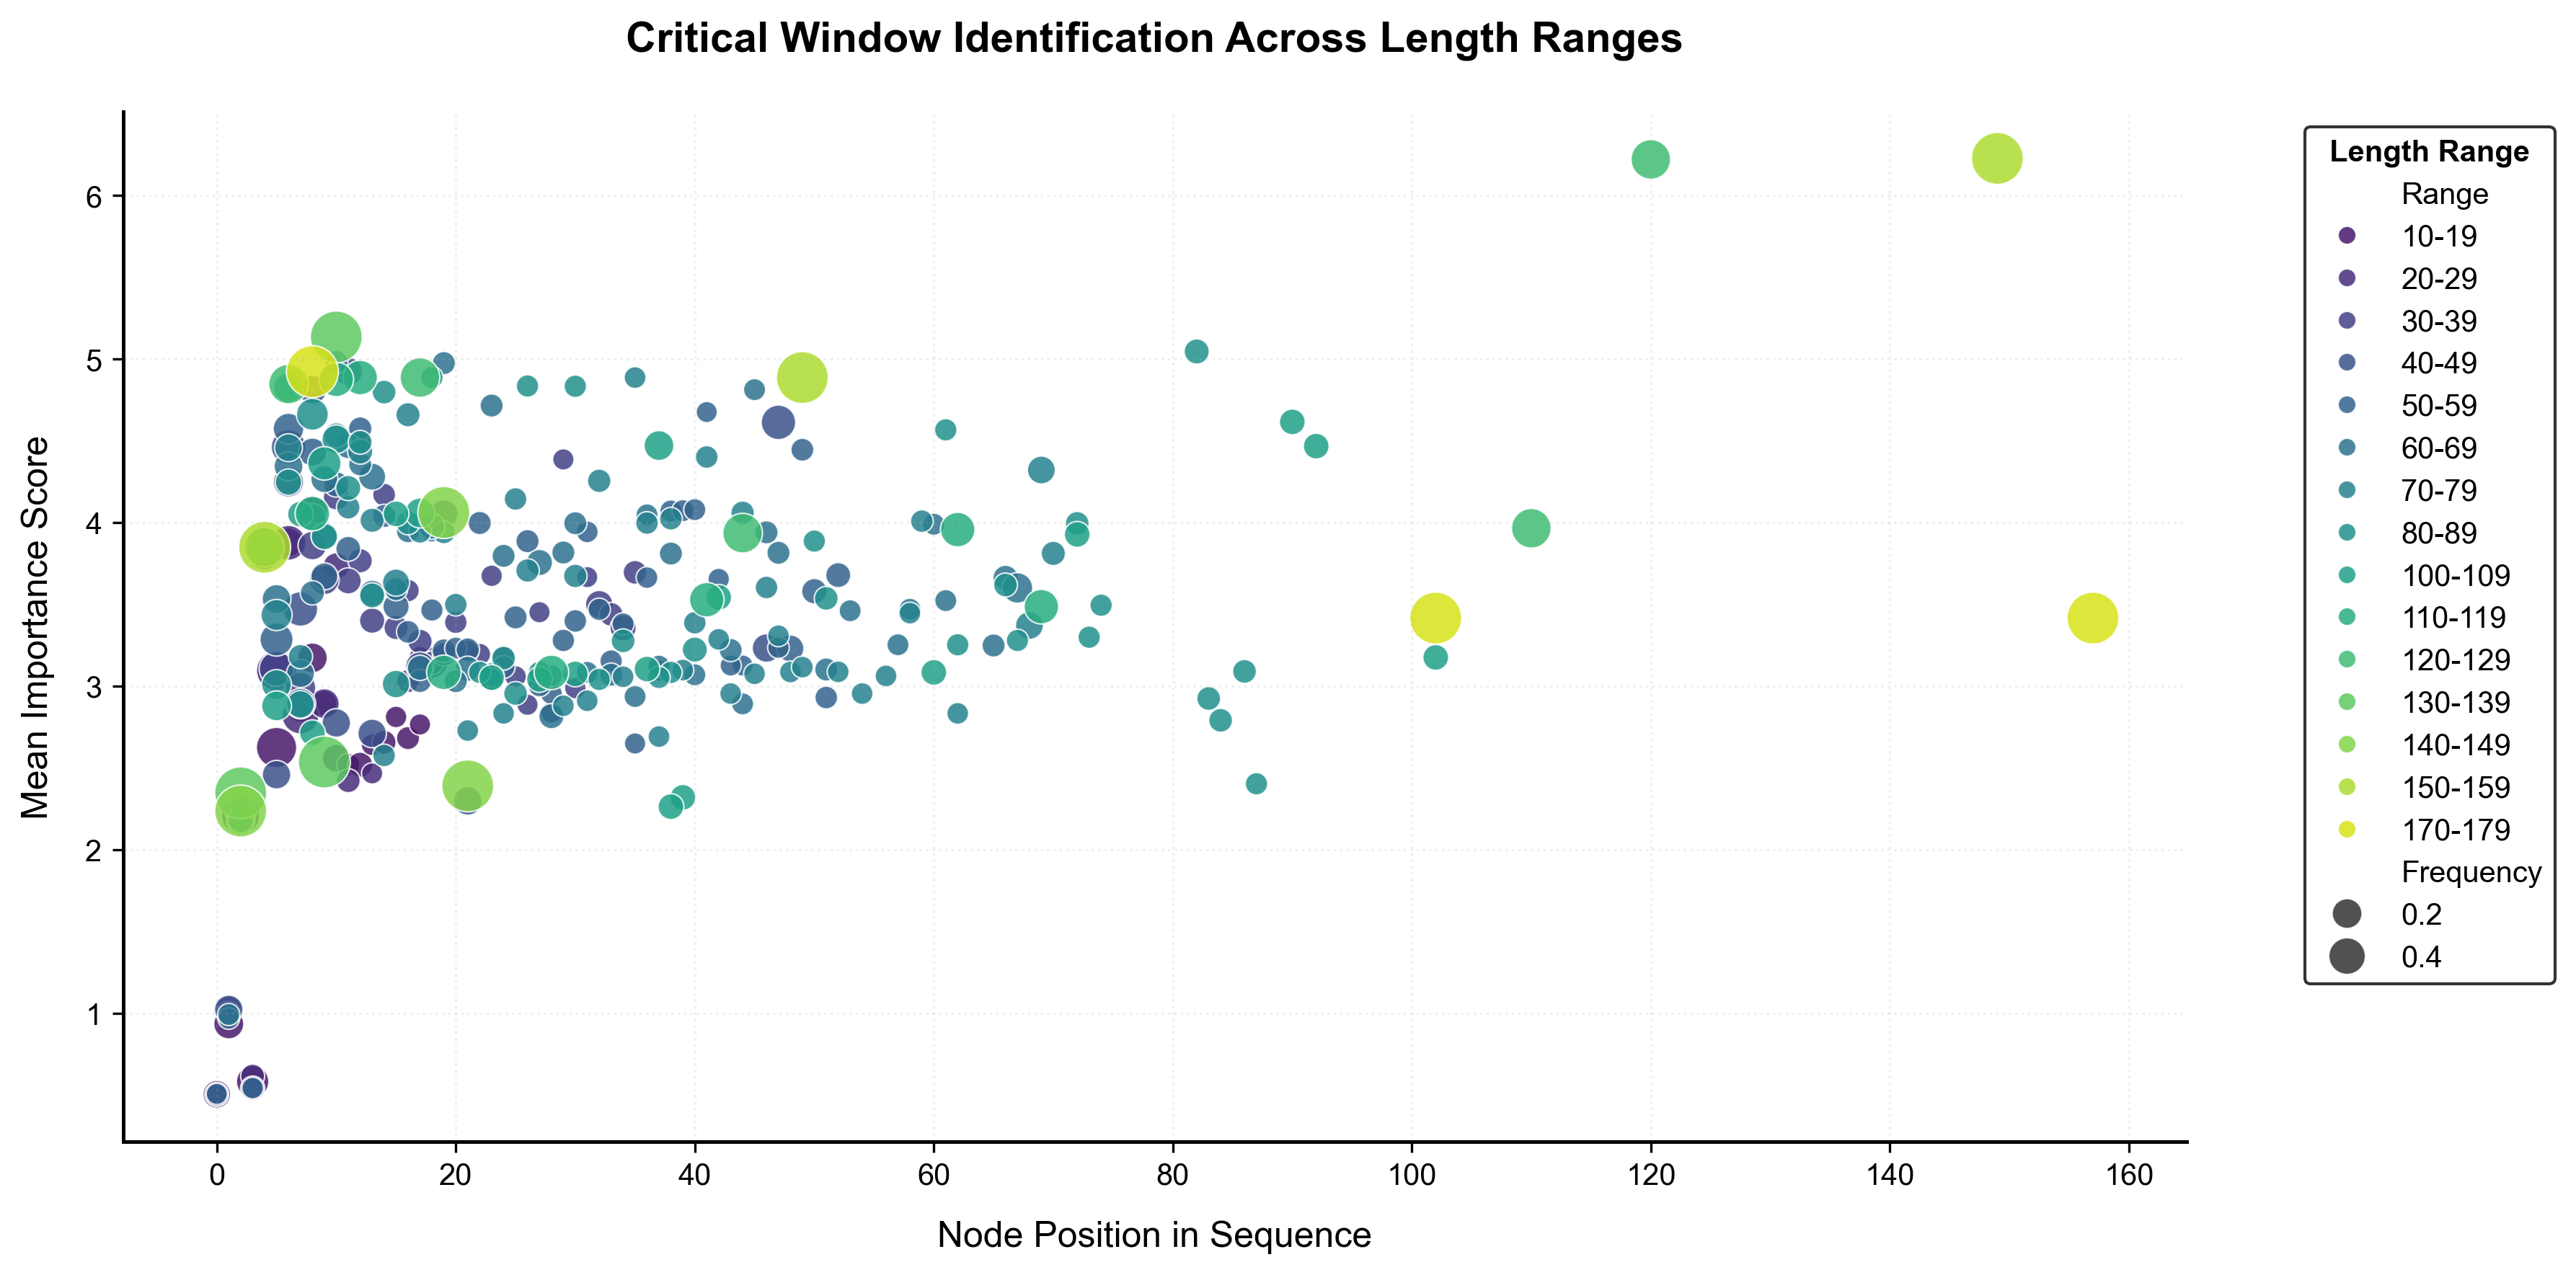

          Comparison Mean Diff t-statistic    p-value Cohen's d Significance  \
5     10-19 vs 70-79    -1.077       -5.60  4.106e-07     -1.53           **   
4     10-19 vs 60-69    -1.122       -5.13  3.079e-06     -1.43           **   
6     10-19 vs 80-89    -1.132       -4.97  6.471e-06     -1.41           **   
9   10-19 vs 120-129    -2.137       -4.87  7.294e-05     -2.29           **   
72  70-79 vs 120-129    -1.060       -3.82  3.277e-04     -1.65           **   

    n1  n2  
5   18  53  
4   18  46  
6   18  41  
9   18   6  
72  53   6  


C:\Users\david\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


In [5]:
from timegnn import (
    get_length_bins_from_attention, compute_importance_stats,
    plot_heatmap_from_stats, plot_rank_dominance,
    plot_importance_timeline, plot_importance_timeline_edge,
    plot_edge_attention_correlation,
    plot_critical_windows, generate_pairwise_ttest_table,
    get_top_significant_ranges,
    calculate_window_metrics, plot_window_metrics,
)

attention = result.get("attention")

if attention:
    length_bins, _ = get_length_bins_from_attention(attention, bin_size=10)
    range_stats, range_importances, _ = compute_importance_stats(attention, length_bins)

    # ── Importance heatmap ──
    plot_heatmap_from_stats(range_stats, range_importances)

    # ── Rank dominance ──
    plot_rank_dominance(range_stats, title="Top-Node Dominance (BPI 2012)")

    # ── Importance timeline ──
    plot_importance_timeline(attention, min_length=5, max_length=20)

    # ── Edge-attention correlation (unique to this model variant) ──
    try:
        plot_edge_attention_correlation(attention)
    except Exception as exc:
        print(f"Edge-attention correlation skipped: {exc}")

    # ── Statistical tests ──
    window_stats = plot_critical_windows(attention, length_bins, compare_ranges=None)
    pairwise = generate_pairwise_ttest_table(window_stats, length_bins)
    top_sig, _ = get_top_significant_ranges(pairwise, num_top=5)
    print(top_sig)

    df_metrics = calculate_window_metrics(attention, length_bins)
    plot_window_metrics(df_metrics)
else:
    print("No attention data was returned.")

## 5. Summary

This is the **flagship experiment** of the TimeGNN library:
the most expressive model on the richest dataset.

The attention analysis reveals:
- How temporal decay shapes the model's memory horizon
- Whether edge-type embeddings correlate with attention weights
- Which sequence lengths / temporal windows are most statistically distinct

For case-level outcome prediction on the same dataset, see **`gat_outcome_bpi_full`**.